# E-Commerce Sales Analysis
### Tools: PostgreSQL + Python + Jupyter Notebook

## Project Overview
Analysis of an Indian e-commerce database with 5 tables:
- **customers** — 20 customers across Indian cities
- **products** — 15 products across 6 categories
- **orders** — 30 orders with status tracking
- **order_items** — 45 line items
- **payments** — 26 payment records

## Business Questions
1. Which city generates the most revenue?
2. What are the top products by revenue?
3. How is monthly revenue trending?
4. What is the customer segment breakdown?
5. Which payment method is most popular?

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'psycopg2-binary'], check=True)

CompletedProcess(args=['pip', 'install', 'psycopg2-binary'], returncode=0)

In [4]:
engine = create_engine(
    "postgresql://postgres:sa@localhost:5433/ecommerce_sql1"
)

try:
    with engine.connect() as conn:
        print("Connected to PostgreSQL successfully!")
except Exception as e:
    print(f"Connection failed: {e}")

Connected to PostgreSQL successfully!


In [5]:
# Load All Tables into Pandas DataFrames
customers   = pd.read_sql("SELECT * FROM customers",   engine)
products    = pd.read_sql("SELECT * FROM products",    engine)
orders      = pd.read_sql("SELECT * FROM orders",      engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)
payments    = pd.read_sql("SELECT * FROM payments",    engine)

print(f"customers   : {len(customers)} rows")
print(f"products    : {len(products)} rows")
print(f"orders      : {len(orders)} rows")
print(f"order_items : {len(order_items)} rows")
print(f"payments    : {len(payments)} rows")

customers   : 20 rows
products    : 15 rows
orders      : 30 rows
order_items : 45 rows
payments    : 26 rows


In [6]:
# Quick Data Overview
print("CUSTOMERS TABLE")
print("-" * 40)
display(customers.head())

print("\nPRODUCTS TABLE")
print("-" * 40)
display(products.head())

print("\nORDERS TABLE")
print("-" * 40)
display(orders.head())

CUSTOMERS TABLE
----------------------------------------


,customer_id,name,email,city,signup_date
0,1,Arjun Sharma,arjun@gmail.com,Chennai,2023-01-15
1,2,Priya Nair,priya@gmail.com,Bangalore,2023-02-20
2,3,Rahul Verma,rahul@gmail.com,Delhi,2023-03-05
3,4,Sneha Iyer,sneha@gmail.com,Chennai,2023-03-18
4,5,Karthik Raj,karthik@gmail.com,Hyderabad,2023-04-01



PRODUCTS TABLE
----------------------------------------


,product_id,name,category,price
0,1,Wireless Earbuds,Electronics,1499.0
1,2,Mechanical Keyboard,Electronics,3299.0
2,3,USB-C Hub,Electronics,899.0
3,4,Yoga Mat,Fitness,699.0
4,5,Resistance Bands Set,Fitness,349.0



ORDERS TABLE
----------------------------------------


,order_id,customer_id,order_date,status
0,1,1,2024-01-05,delivered
1,2,2,2024-01-12,delivered
2,3,3,2024-01-20,delivered
3,4,4,2024-02-03,delivered
4,5,5,2024-02-14,shipped


In [7]:
# Revenue by City
city_revenue_query = """
    SELECT c.city, SUM(p.amount) AS total_revenue
    FROM payments p
    JOIN orders    o ON p.order_id    = o.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.city
    ORDER BY total_revenue DESC
"""
city_revenue = pd.read_sql(city_revenue_query, engine)
display(city_revenue)

,city,total_revenue
0,Chennai,20570.0
1,Bangalore,9483.0
2,Mumbai,8196.0
3,Delhi,7797.0
4,Kochi,5695.0
5,Hyderabad,4095.0
6,Ahmedabad,1398.0


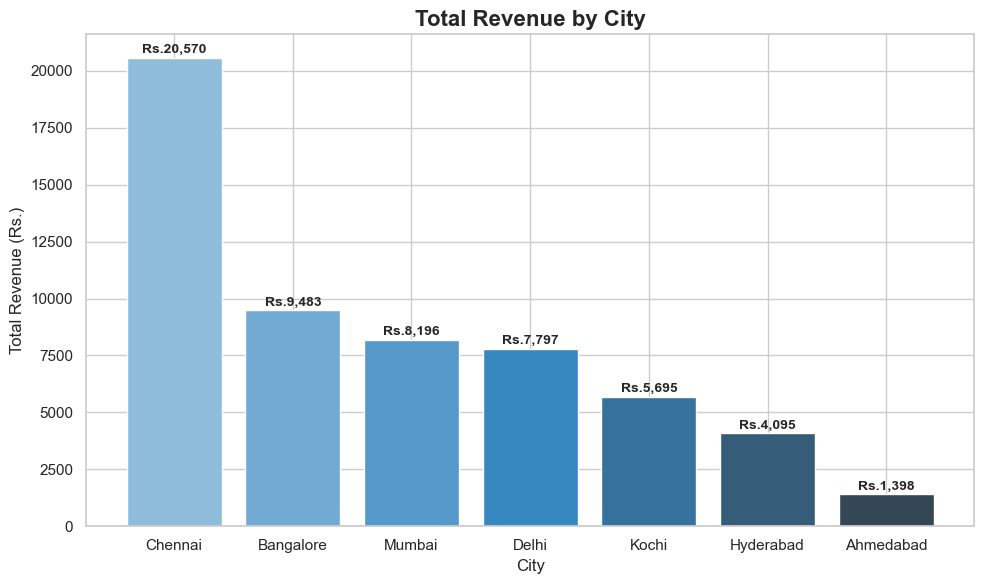

In [8]:
# Chart 1 - Revenue by City
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    city_revenue['city'],
    city_revenue['total_revenue'],
    color=sns.color_palette("Blues_d", len(city_revenue))
)

# Add value labels on top of each bar
for bar, val in zip(bars, city_revenue['total_revenue']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'Rs.{val:,.0f}',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Total Revenue by City', fontsize=16, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Total Revenue (Rs.)')
plt.tight_layout()
plt.savefig('chart1_revenue_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Top Products by Revenue
top_products_query = """
    SELECT
        p.name AS product_name,
        p.category,
        SUM(oi.quantity * oi.unit_price) AS total_revenue,
        SUM(oi.quantity)                 AS units_sold
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.name, p.category
    ORDER BY total_revenue DESC
    LIMIT 8
"""
top_products = pd.read_sql(top_products_query, engine)
display(top_products)

,product_name,category,total_revenue,units_sold
0,Air Fryer,Kitchen,9998.0,2
1,Mechanical Keyboard,Electronics,9897.0,3
2,Wireless Earbuds,Electronics,8994.0,6
3,Running Shoes,Clothing,7497.0,3
4,Protein Powder 1kg,Health,4796.0,4
5,Cotton T-Shirt,Clothing,4389.0,11
6,USB-C Hub,Electronics,3596.0,4
7,Stainless Steel Bottle,Kitchen,3294.0,6


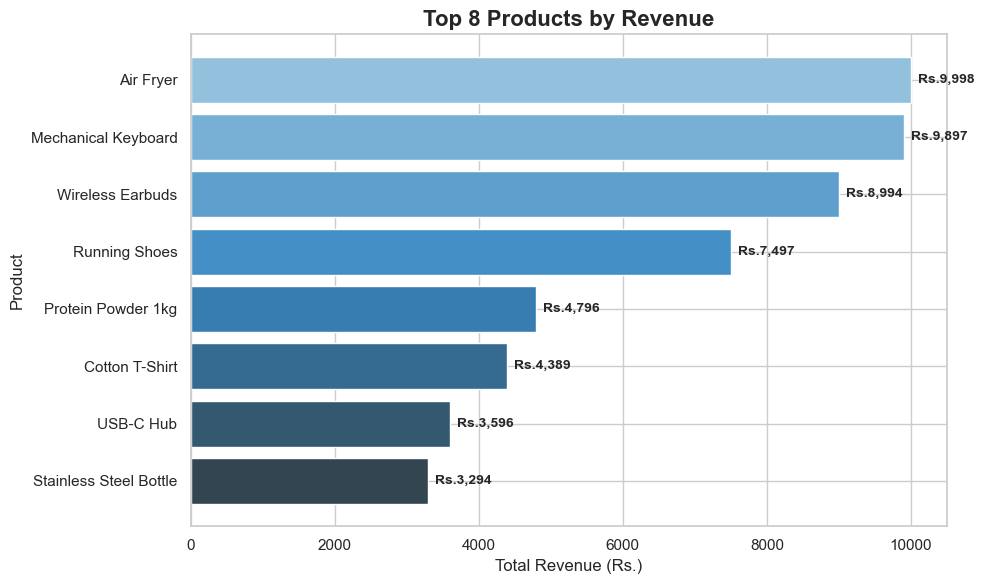

Insight: Air Fryer generates highest revenue despite fewer orders.


In [13]:
# Chart 2 - Top Products by Revenue
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_products['product_name'],
    top_products['total_revenue'],
    color=sns.color_palette("Blues_d", len(top_products))
)

for bar, val in zip(bars, top_products['total_revenue']):
    ax.text(
        val + 100,
        bar.get_y() + bar.get_height() / 2,
        f'Rs.{val:,.0f}',
        va='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Top 8 Products by Revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Revenue (Rs.)')
ax.set_ylabel('Product')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Air Fryer generates highest revenue despite fewer orders.")

In [14]:
# Monthly Revenue Trend
monthly_query = """
    SELECT
        DATE_TRUNC('month', paid_at)::DATE AS month,
        SUM(amount)                        AS monthly_revenue,
        COUNT(*)                           AS transactions
    FROM payments
    GROUP BY DATE_TRUNC('month', paid_at)::DATE
    ORDER BY month
"""
monthly = pd.read_sql(monthly_query, engine)
monthly['month'] = pd.to_datetime(monthly['month'])
display(monthly)

,month,monthly_revenue,transactions
0,2024-01-01,7094.0,3
1,2024-02-01,5942.0,3
2,2024-03-01,6097.0,2
3,2024-04-01,7094.0,3
4,2024-05-01,7095.0,3
5,2024-06-01,3490.0,2
6,2024-07-01,3889.0,2
7,2024-08-01,3796.0,2
8,2024-09-01,7195.0,3
9,2024-10-01,4744.0,2


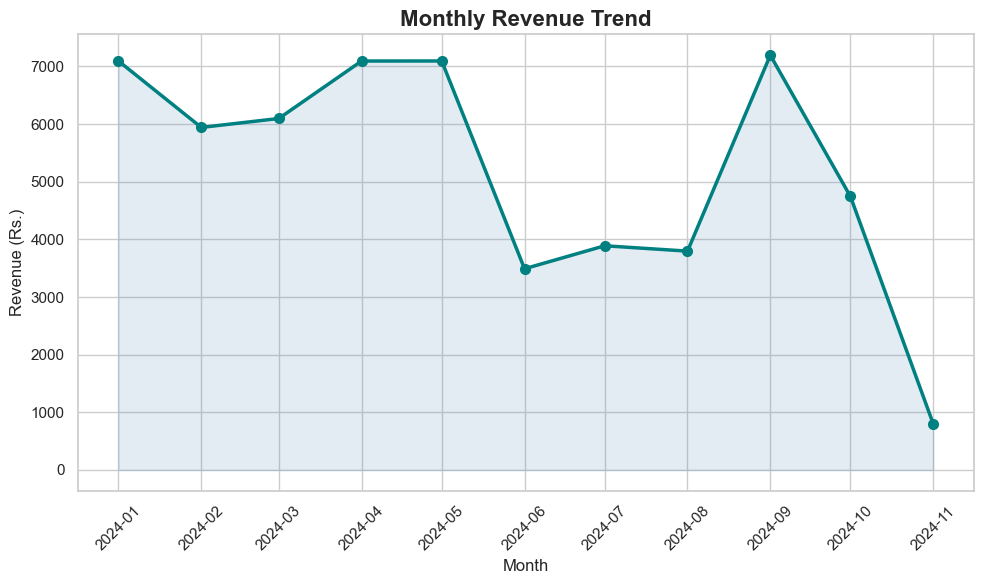

Insight: Revenue shows consistent activity throughout 2024.


In [16]:
# Chart 3 - Monthly Revenue Trend
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    monthly['month'],
    monthly['monthly_revenue'],
    color='teal',
    linewidth=2.5,
    marker='o',
    markersize=7
)

ax.fill_between(
    monthly['month'],
    monthly['monthly_revenue'],
    alpha=0.15,
    color='steelblue'
)

ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Revenue shows consistent activity throughout 2024.")

In [24]:
# Customer Segments
segments_query = """
    SELECT
        CASE
            WHEN SUM(p.amount) > 8000 THEN 'VVIP'
            WHEN SUM(p.amount) > 5000 THEN 'VIP'
            WHEN SUM(p.amount) > 2000 THEN 'Regular'
            WHEN SUM(p.amount) > 0    THEN 'Low Spender'
            ELSE 'No Purchase'
        END AS segment,
        COUNT(DISTINCT c.customer_id) AS customer_count
    FROM customers c
    LEFT JOIN orders   o ON c.customer_id = o.customer_id
    LEFT JOIN payments p ON o.order_id    = p.order_id
    GROUP BY c.customer_id
"""
segments_raw = pd.read_sql(segments_query, engine)

# Fix order
segment_order = ['VVIP', 'VIP', 'Regular', 'Low Spender', 'No Purchase']
segments_raw['segment'] = pd.Categorical(
    segments_raw['segment'],
    categories=segment_order,
    ordered=True
)
segments = segments_raw.groupby('segment', observed=True)['customer_count'].sum().reset_index()
display(segments)

,segment,customer_count
0,VVIP,1
1,VIP,2
2,Regular,9
3,Low Spender,6
4,No Purchase,2


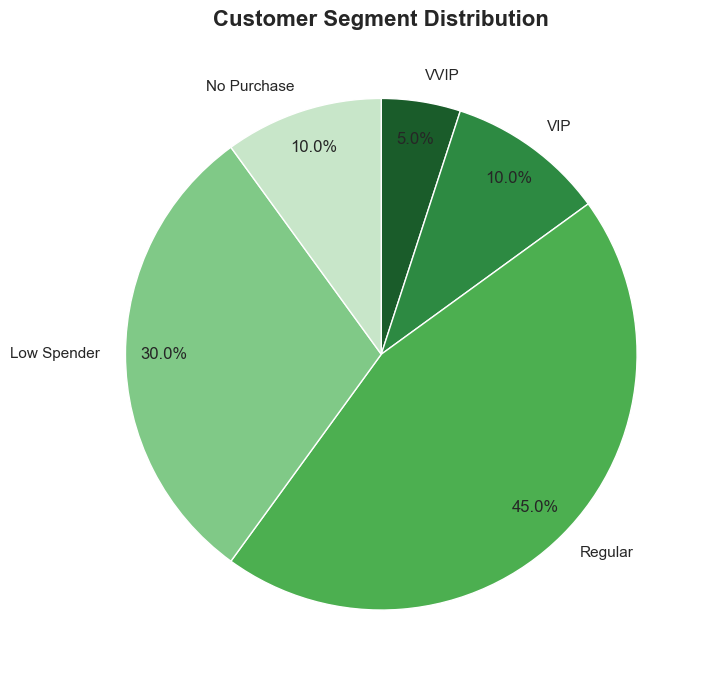

Insight: 45% are regular customers - big opportunity for upselling to VIP.


In [55]:
# Chart 4 - Customer Segments Pie Chart
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#1a5c2a', '#2d8a42', '#4CAF50', '#80c987', '#c8e6c9']

ax.pie(
    segments['customer_count'],
    labels=segments['segment'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    counterclock=False,
    pctdistance=0.85
)

ax.set_title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: 45% are regular customers - big opportunity for upselling to VIP.")

,method,total_transactions,total_revenue
0,credit_card,6,17787.0
1,UPI,10,16420.0
2,netbanking,4,10294.0
3,debit_card,3,8094.0
4,COD,3,4639.0


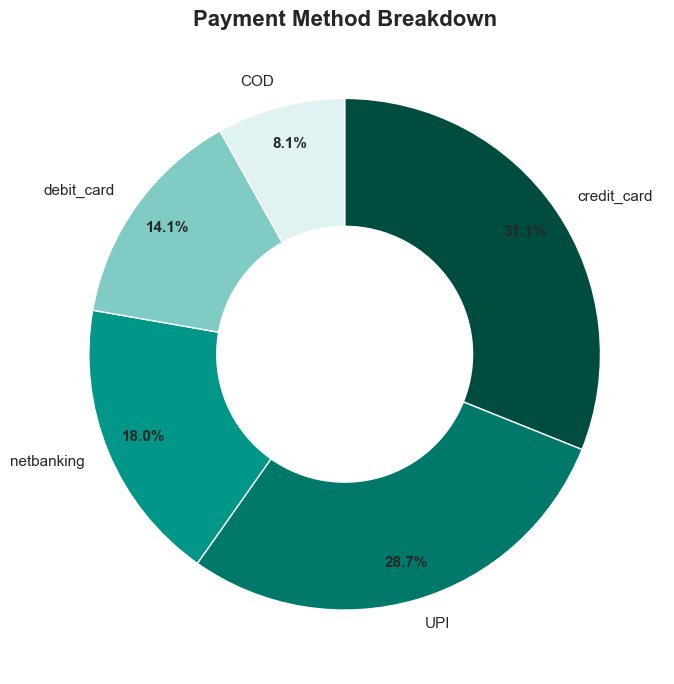

Insight: UPI is the most popular payment method - reflects Indian digital payment trends.


In [56]:
# Chart 5 - Payment Methods Donut Chart
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#004d40', '#00796b', '#009688', '#80cbc4', '#e0f2f1']
wedges, texts, autotexts = ax.pie(
    payment_df['total_revenue'],
    labels=payment_df['method'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    counterclock=False,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5)
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Payment Method Breakdown', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: UPI is the most popular payment method - reflects Indian digital payment trends.")

In [57]:
# Key Business Insights Summary
print("=" * 50)
print("      KEY BUSINESS INSIGHTS")
print("=" * 50)

total_revenue   = pd.read_sql("SELECT SUM(amount) FROM payments", engine).iloc[0,0]
total_orders    = pd.read_sql("SELECT COUNT(*) FROM orders", engine).iloc[0,0]
avg_order_value = pd.read_sql("SELECT ROUND(AVG(amount)::numeric,2) FROM payments", engine).iloc[0,0]

print(f"\nTotal Revenue     : Rs.{total_revenue:,.2f}")
print(f"Total Orders      : {total_orders}")
print(f"Avg Order Value   : Rs.{avg_order_value:,.2f}")
print(f"\nTop City          : Chennai (Rs.20,570)")
print(f"Top Product       : Air Fryer (Rs.9,998)")
print(f"Top Payment       : Credit Card (31.1%)")
print(f"VVIP Customer     : Anjali Das (Rs.8,196)")
print("=" * 50)

      KEY BUSINESS INSIGHTS

Total Revenue     : Rs.57,234.00
Total Orders      : 30
Avg Order Value   : Rs.2,201.31

Top City          : Chennai (Rs.20,570)
Top Product       : Air Fryer (Rs.9,998)
Top Payment       : Credit Card (31.1%)
VVIP Customer     : Anjali Das (Rs.8,196)


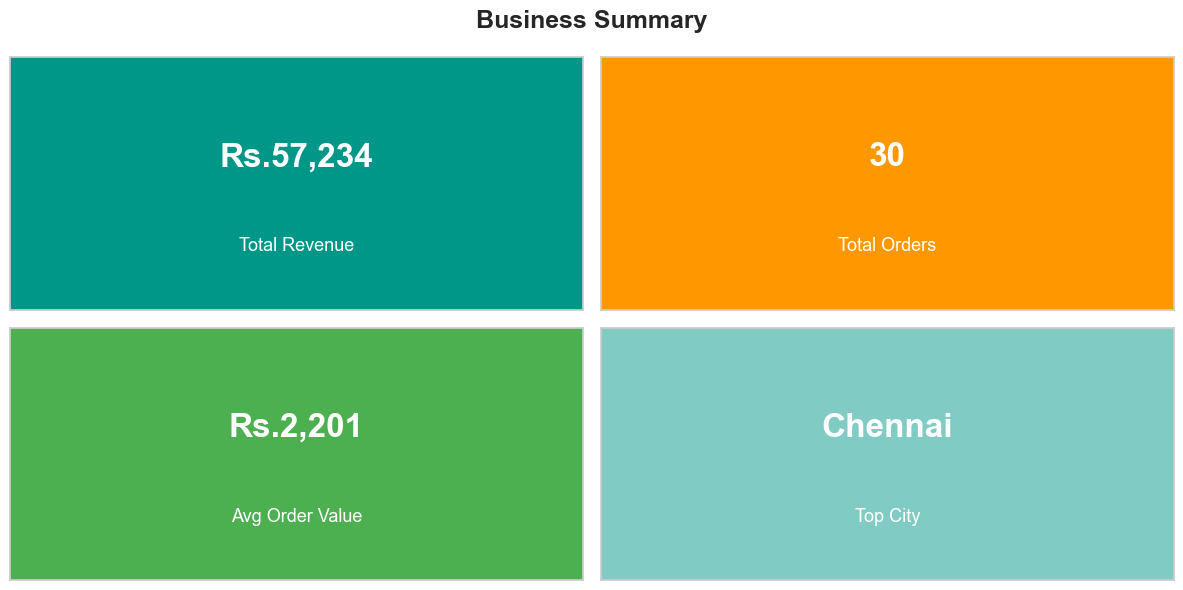

In [68]:
# Summary KPI Dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Business Summary', fontsize=18, fontweight='bold')

kpis = [
    ('Total Revenue', f'Rs.{total_revenue:,.0f}', '#009688'),
    ('Total Orders', str(total_orders), '#FF9800'),
    ('Avg Order Value', f'Rs.{avg_order_value:,.0f}', '#4CAF50'),
    ('Top City', 'Chennai', '#80cbc4'),
]

for ax, (title, value, color) in zip(axes.flatten(), kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=24, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=13, color='white',
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('summary_kpi.png', dpi=150, bbox_inches='tight')
plt.show()